In [ ]:
from pathlib import Path
import sys
import importlib

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.style import (  # noqa: E402
    save_figure,
    WIDTHS,
    )

from sse_detection import lib as sselib  # noqa: E402

# Reload local package after editing source files
importlib.reload(sselib)


OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "sse_outputs"
FIG_DIR = PROJECT_ROOT / "sse_detection" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

def save_plot(
    plot,
    stem,
    width: WIDTHS = "double",
    width_in=None,
    height_in=3.5,
    
):
    if not SAVE_FIGURES:
        return
    save_figure(
        plot,
        FIG_DIR / stem,
        width=width,
        width_in=width_in,
        height_in=height_in,
        save_pdf=True,
        save_png=True,
    )

## Load Outputs

`load_sse_outputs` returns a container with the static parquet tables: `node_stats`, `edge_table`, `candidate_review`, `meta_summary`.

In [5]:
outs = sselib.load_sse_outputs(OUTPUT_DIR)
node_stats = outs.node_stats
min_size = node_stats[node_stats["sse_candidate"]]["cluster_size"].min()
edge_table = outs.edge_table
candidate_review = outs.candidate_review
meta_summary = outs.meta_summary
candidates = outs.candidates

print(f"node_stats: {node_stats.shape[0]:,} rows x {node_stats.shape[1]:,} columns")
print(f"edge_table: {edge_table.shape[0]:,} rows")
print(f"candidate nodes: {len(candidates):,}")
print(f"min candidate cluster size: {min_size}")
print(f"background nodes: {(node_stats["cluster_size"].ge(min_size)).sum() - len(candidates):,}")

node_stats: 99,006 rows x 160 columns
edge_table: 41,747 rows
candidate nodes: 10,619
min candidate cluster size: 3
background nodes: 19,087


In [9]:
node_stats["clade"].nunique()

30

## Output Summary Table

In [3]:
summary = pd.DataFrame(
    [
        ("node-clusters", len(node_stats)),
        ("directed edges", len(edge_table)),
        ("meta-clusters", meta_summary["meta_cluster_id"].nunique()),
        ("SSE-like candidate nodes", int(node_stats["sse_candidate"].sum())),
        ("candidate share of nodes", float(node_stats["sse_candidate"].mean())),
        (f"background nodes (>= {min_size})", int(node_stats["cluster_size"].ge(min_size).sum() - node_stats["sse_candidate"].sum())),
        (f"background share of nodes (>= {min_size})", float(node_stats["cluster_size"].ge(min_size).mean() - node_stats["sse_candidate"].mean())),
        ("unique candidate categories", candidates["sse_category"].nunique()),
    ],
    columns=["quantity", "value"],
)

summary["display_value"] = summary["value"].map(
    lambda x: (
        f"{x:,.1%}"
        if isinstance(x, float) and x < 1
        else f"{x:,.0f}"
        if pd.notna(x)
        else "NA"
    )
)

display(summary[["quantity", "display_value"]])

,quantity,display_value
0,node-clusters,"99,006"
1,directed edges,"41,747"
2,meta-clusters,"57,354"
3,SSE-like candidate nodes,"10,619"
4,candidate share of nodes,10.7%
5,background nodes (>= 3),"19,087"
6,background share of nodes (>= 3),19.3%
7,unique candidate categories,19


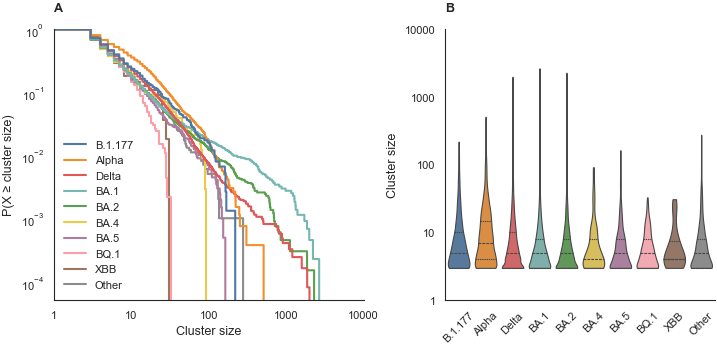

In [4]:
fig = sselib.plot_cluster_size_distribution(
    node_stats, min_size=min_size
)
display(fig)
save_plot(fig, "fig01_cluster_size",  height_in=3.5)

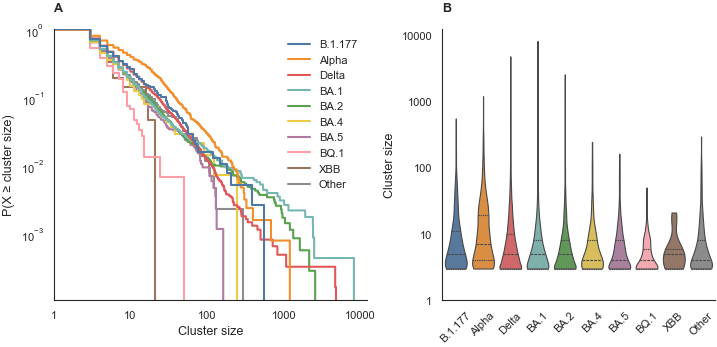

In [5]:
fig = sselib.plot_cluster_size_distribution(
    meta_summary, size_col="n_sequences", min_size=min_size
)
display(fig)
save_plot(fig, "fig02_meta_cluster_size", height_in=3.5)

In [6]:
sse_roles = node_stats["sse_role"].dropna().unique()

role_summary = (
    node_stats
    .groupby("meta_cluster_id")["sse_role"]
    .nunique()
    .reset_index(name="n_roles_represented")
)

max_roles = role_summary["n_roles_represented"].max()

meta_ids = role_summary[
    role_summary["n_roles_represented"] == max_roles
    ]["meta_cluster_id"].tolist()

meta_ids

['AM00001', 'AM00002', 'AM00009', 'AM00012', 'AM00027', 'AM00032', 'AM00049']

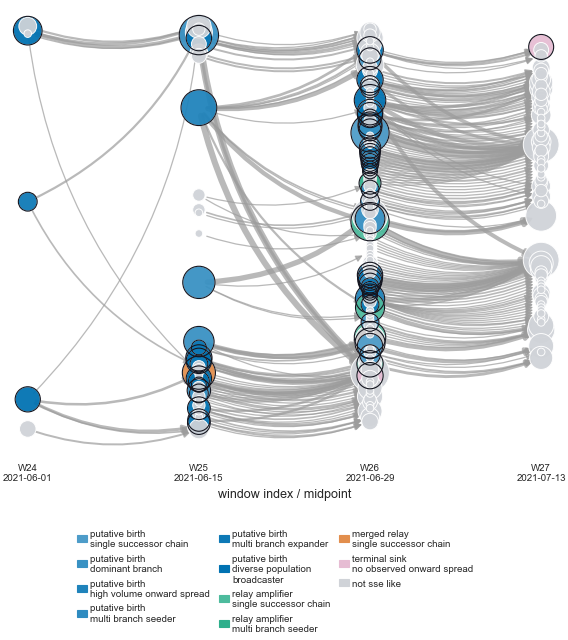

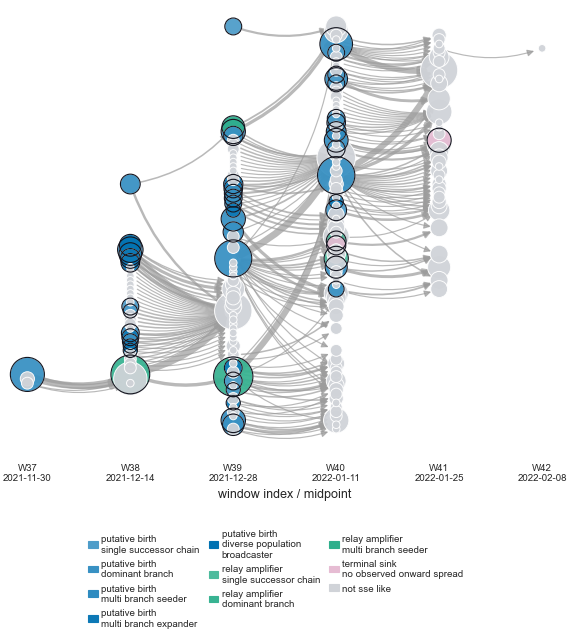

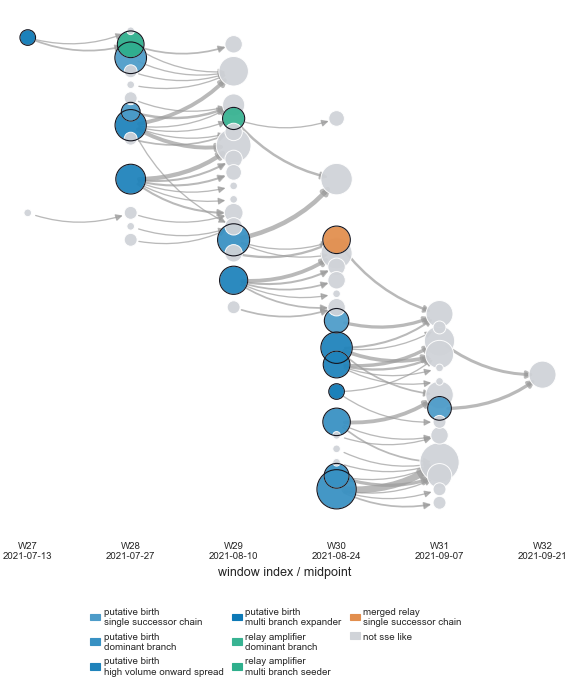

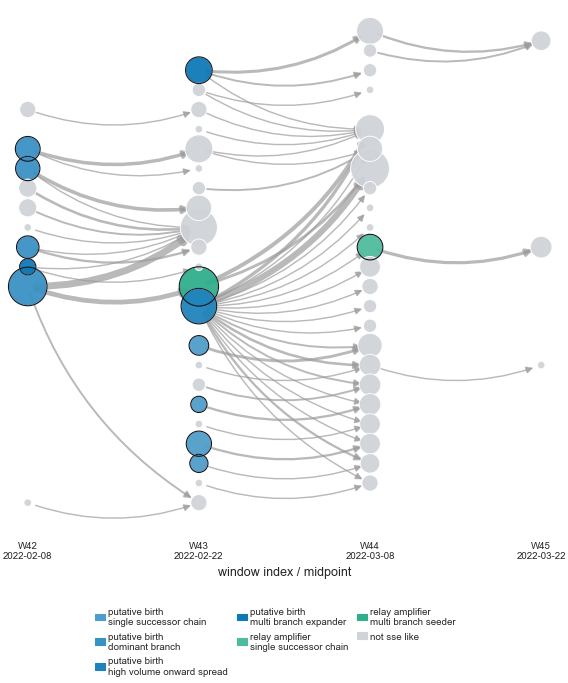

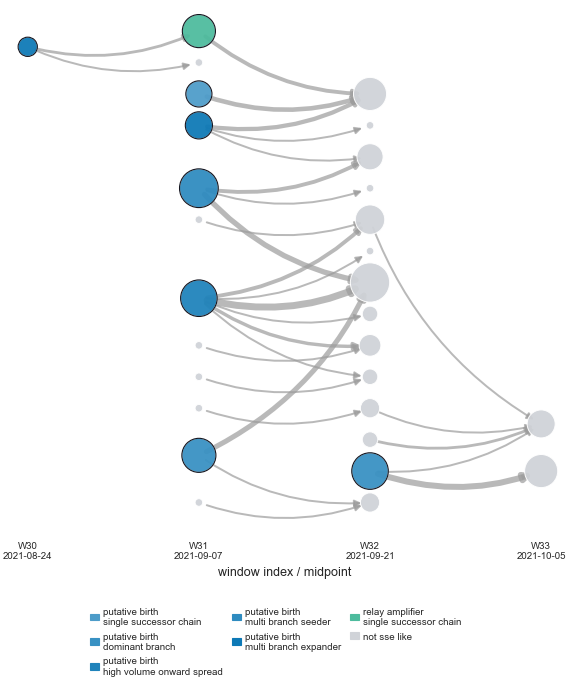

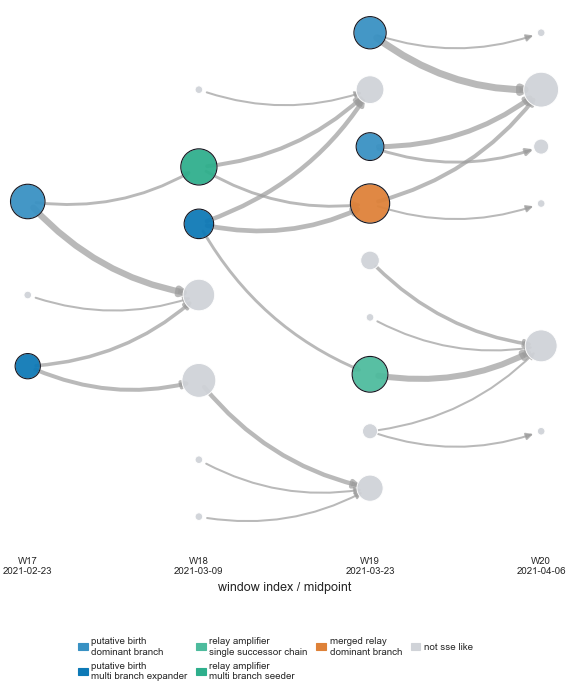

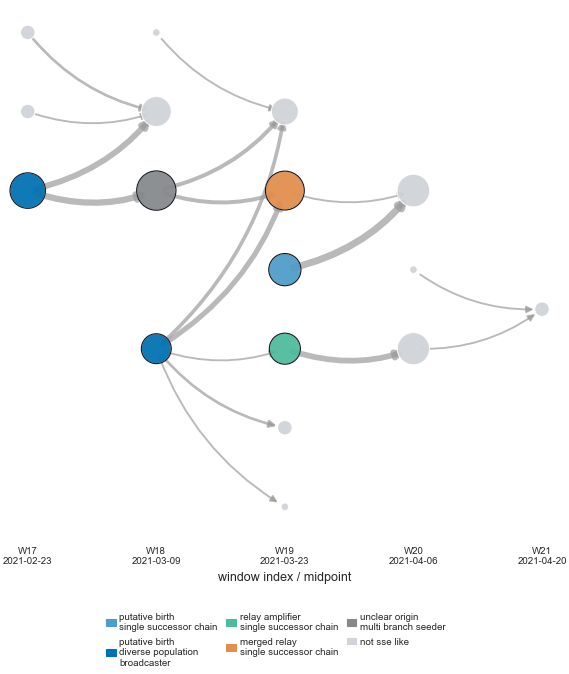

In [7]:
for meta_id in meta_ids[:10]:
    fig = sselib.plot_meta_cluster_subgraph(
        node_stats=node_stats,
        edge_table=edge_table,
        meta_cluster_id=meta_id,
        color_by="sse_category",
        annotate_top_n=0,
        rankdir="LR",
        height_in=8,
    )
    display(fig)
    save_plot(fig, f"fig03_subgraph_{meta_id}_exemplar", height_in=8.0)

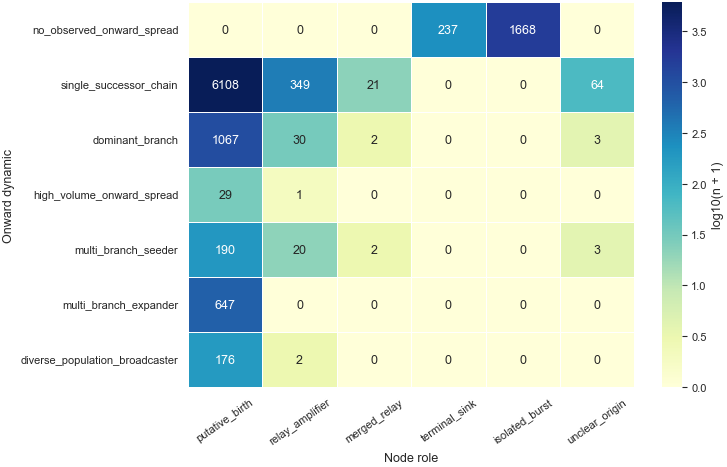

In [9]:
fig = sselib.plot_role_dynamic_heatmap(candidates)
display(fig)
save_plot(fig, "fig04_role_onward_heatmap", height_in=5)

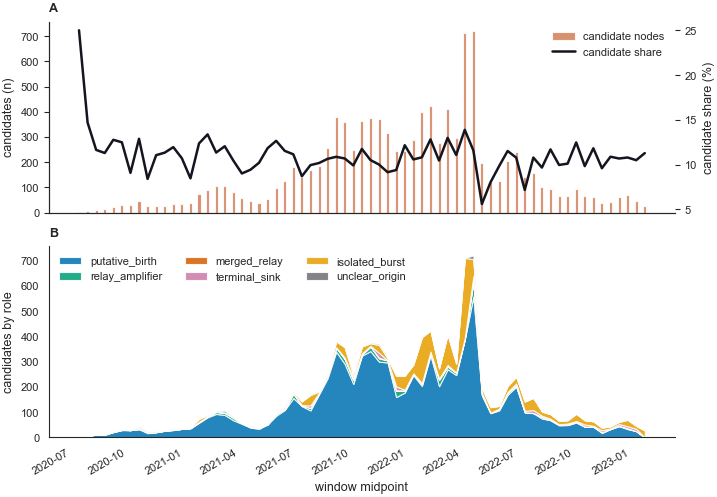

In [10]:
fig = sselib.plot_candidate_rate_over_time(node_stats)
display(fig)
save_plot(fig, "fig05_candidate_rate_over_time", height_in=5)

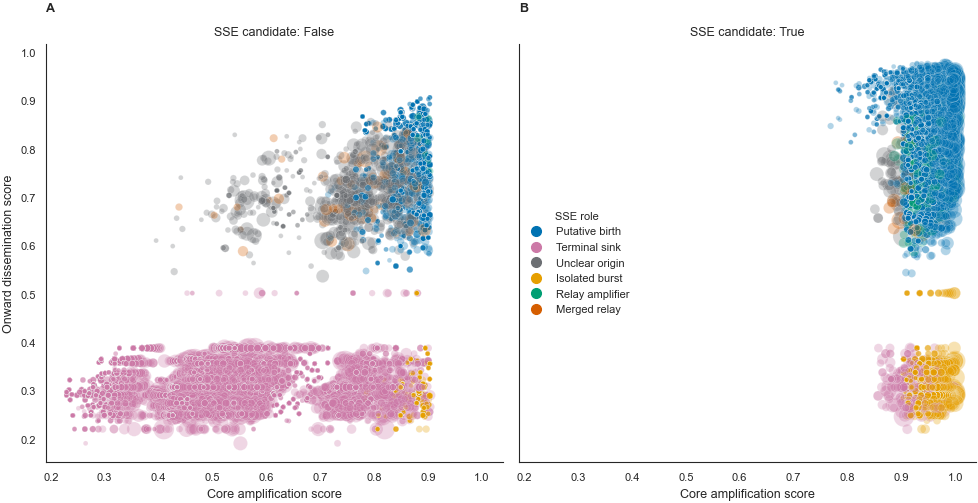

In [13]:
fig = sselib.plot_core_metric_space(node_stats, min_size=min_size)
display(fig)
save_plot(fig, "fig06_metric_space_scatter", height_in=3.5)

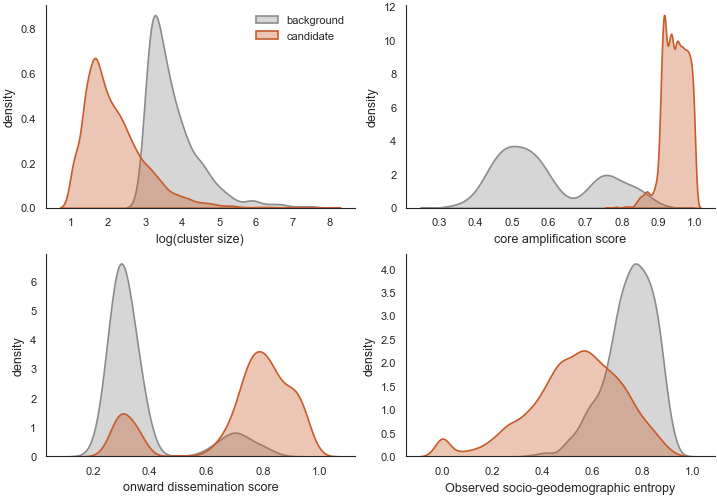

In [17]:
fig = sselib.plot_composite_distributions(node_stats, min_size=min_size, height_in=5)
display(fig)
save_plot(fig, "fig07_composite_score_distributions", height_in=5)

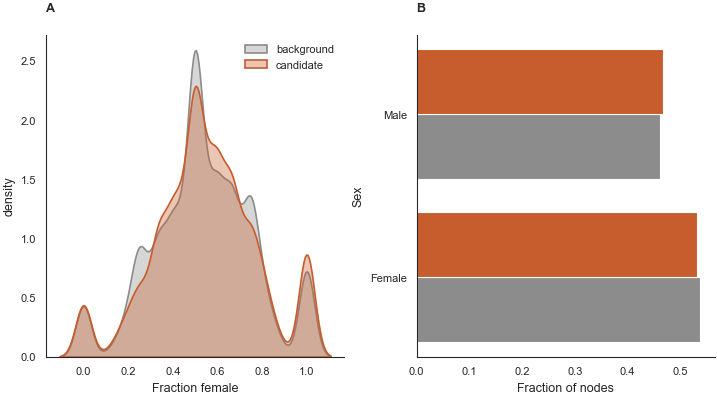

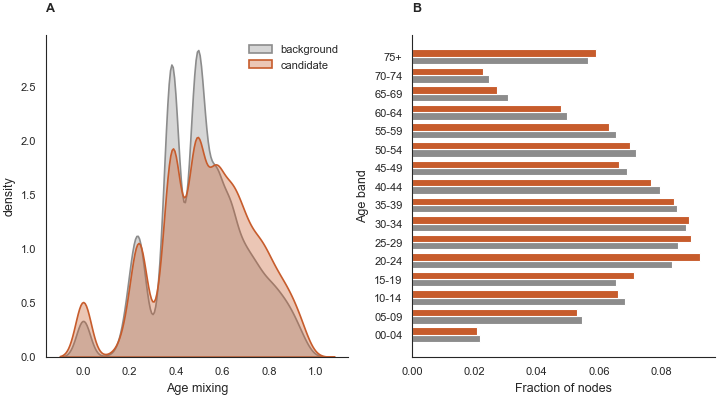

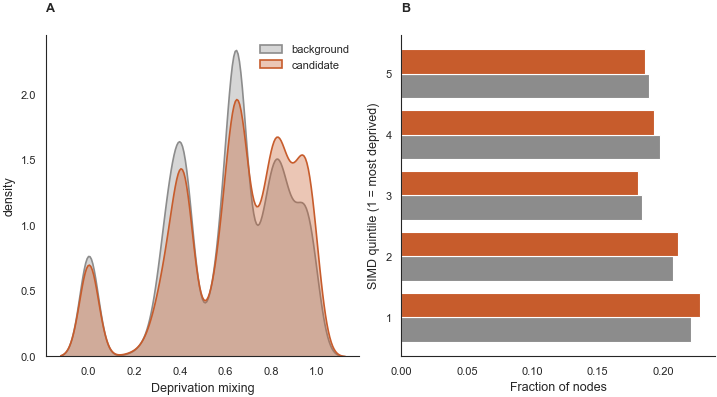

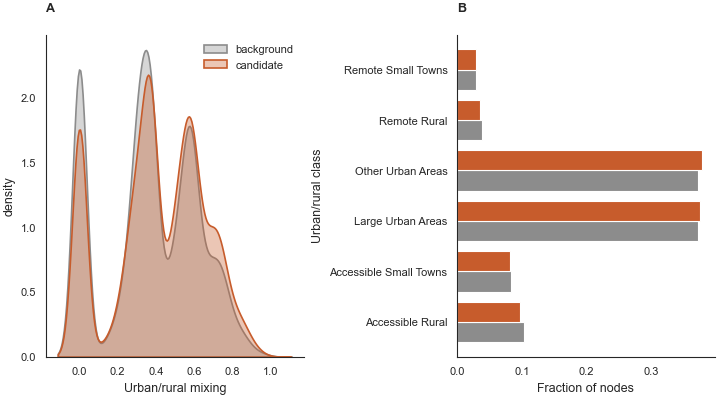

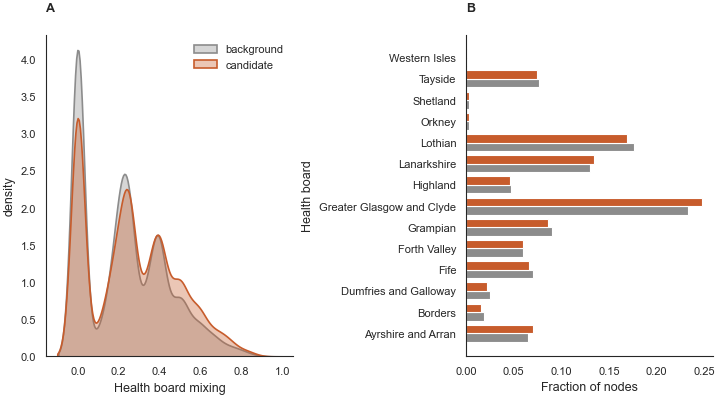

In [18]:
socio_demo_cols = [
    ("sex_counts", "fraction_female", ("Fraction female", "Sex")),
    ("age_band_counts", "age_entropy_obs",("Age mixing",  "Age band")),
    ("simd_quintile_counts","simd_entropy_obs", ("Deprivation mixing", "SIMD quintile (1 = most deprived)")),
    ("urban_rural_class_counts",  "urban_rural_entropy_obs", ("Urban/rural mixing", "Urban/rural class")),
    ("health_board_counts",  "health_board_entropy_obs", ("Health board mixing", "Health board")),
]

for col, score, label in socio_demo_cols:

    fig, _ = sselib.plot_socio_demo_breakdown(
        node_stats, min_size=min_size,
        col=col,
        score=score,
        xlabels=label,
    )
    display(fig)
    save_plot(fig, f"fig08_{col}_{score}_breakdown", height_in=4)